### [McGinley, KAMA, and Kalman: Three Ways to Filter Market Noise](https://medium.com/coding-nexus/60014b014506)

> How adaptive averages and probabilistic filters really differ, and what their behavior teaches about markets

- **McGinley Dynamic: Fixing Lag**
  
  The McGinley Dynamic was created to address a specific frustration with traditional moving averages, particularly EMAs. Fixed smoothing parameters cause averages to lag badly when price accelerates and overreact when price stalls.

- **KAMA: Responsiveness must be Earned**
  
  KAMA, or Kaufman Adaptive Moving Average, takes a more selective approach.
  
  Instead of reacting to distance between price and the average, KAMA measures how efficiently price has moved. It compares net directional movement to total movement over a lookback period. This ratio determines how quickly the average adapts.

- **Kalman filtering: estimating what you cannot directly observe**
  
  Kalman filtering is fundamentally different from both McGinley and KAMA. Instead of smoothing price, it estimates an underlying state.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
def mcginley_dynamic(price, period=14):
    md = np.zeros(len(price))
    md[0] = price.iloc[0]

    for i in range(1, len(price)):
        md[i] = md[i-1] + (price.iloc[i] - md[i-1]) / (
            period * (price.iloc[i] / md[i-1])**4
        )

    return pd.Series(md, index=price.index)

In [3]:
def kama(price, er_period=10, fast=2, slow=30):
    change = price.diff(er_period).abs()
    volatility = price.diff().abs().rolling(er_period).sum()

    er = change / volatility
    er = er.fillna(0.0)

    fast_sc = 2 / (fast + 1)
    slow_sc = 2 / (slow + 1)
    sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2

    kama = np.zeros(len(price))
    kama[0] = price.iloc[0]

    for i in range(1, len(price)):
        kama[i] = kama[i-1] + sc.iloc[i] * (price.iloc[i] - kama[i-1])

    return pd.Series(kama, index=price.index)

In [4]:
def kalman_filter(price, q=1e-5, r=1e-2):
    x_hat = np.zeros(len(price))
    p = np.zeros(len(price))

    x_hat[0] = price.iloc[0]
    p[0] = 1.0

    for k in range(1, len(price)):
        x_pred = x_hat[k-1]
        p_pred = p[k-1] + q

        k_gain = p_pred / (p_pred + r)
        x_hat[k] = x_pred + k_gain * (price.iloc[k] - x_pred)
        p[k] = (1 - k_gain) * p_pred

    return pd.Series(x_hat, index=price.index)

In [5]:
def sma(price, period=50):
    return price.rolling(period).mean()

def ema(price, period=20):
    return price.ewm(span=period, adjust=False).mean()

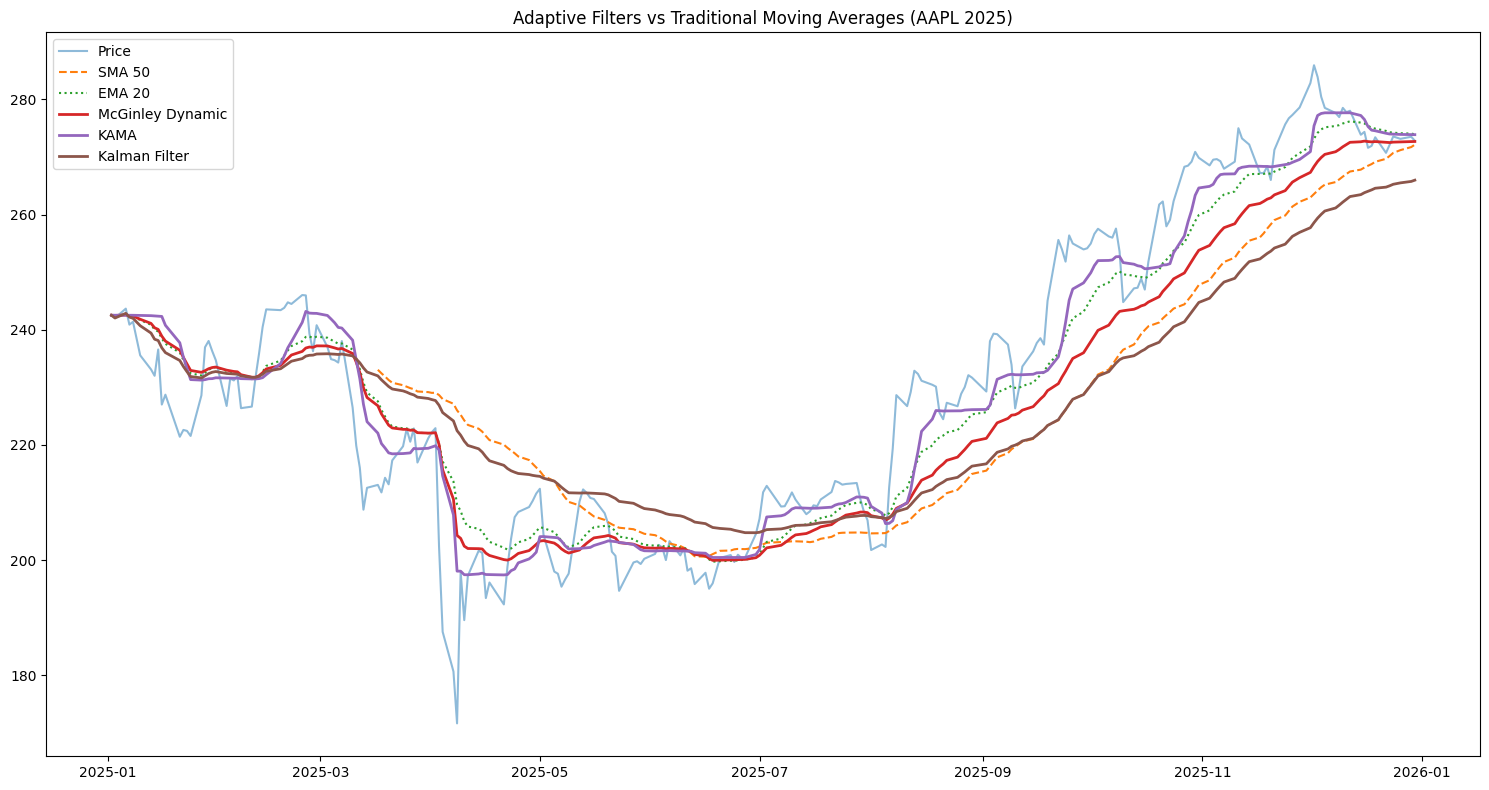

In [6]:
data = yf.download("AAPL", start="2025-01-01", end="2025-12-31", progress=False)
price = data["Close"]

md = mcginley_dynamic(price)
kama_line = kama(price)
kalman_line = kalman_filter(price)
sma_50 = sma(price, 50)
ema_20 = ema(price, 20)

plt.figure(figsize=(15, 8))
plt.plot(price, label="Price", alpha=0.5)
plt.plot(sma_50, label="SMA 50", linestyle="--")
plt.plot(ema_20, label="EMA 20", linestyle=":")

plt.plot(md, label="McGinley Dynamic", linewidth=2)
plt.plot(kama_line, label="KAMA", linewidth=2)
plt.plot(kalman_line, label="Kalman Filter", linewidth=2)

plt.title("Adaptive Filters vs Traditional Moving Averages (AAPL 2025)")
plt.tight_layout()
plt.legend()
plt.show()